# Esperimenti sul dataset con pazienti/malattie

## Il grafo è separato dai componenti di Protein, GO e Gene, togliendo anche gli Article
## Il grafo risultante è schematizzato così:

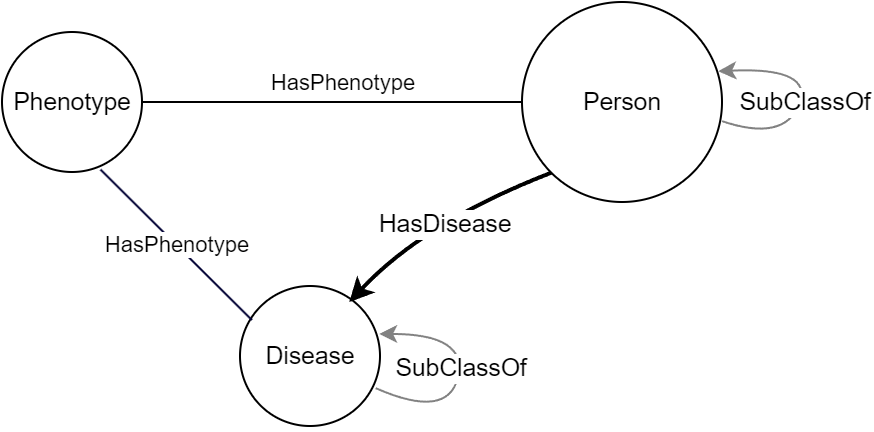

### Il grafo presenta (28'811 nodi e archi 178'320), è stato snellito togliendo gli archi non coinvolti nelle sole malattie associate ai pazienti
### Sono quindi incluse tutte le connessioni che coinvolgono le malattie associate ai paziente e anche le loro malattie "parent"

## Test set creato esclusivamente sugli archi "Has disease"

##  Training senza definire delle feature, solamente sulla struttura del grafo

In [2]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import math
from utilities import carica_fileNew
from sklearn.decomposition import PCA

grid = ["l0.0005|d2", "l0.0005|d3","l0.0005|d10", "l0.0005|d26", "l0.01|d2", "l0.01|d3", "l0.01|d10", "l0.01|d26", "l0.09|d2", "l0.09|d3", "l0.09|d10", "l0.09|d26"]

## Grid search esaustivo sugli iperparametri

In [3]:
from utilities import caricaLogNew

n = 55 #55, 57, 59

dataset = "Pazienti senza features HGCN"
root_dir = "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCNnoGF" + str(n)
root_dir2 = "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCNnoGF" + str(n)

all_val_roc, all_val_ap, all_val_precision, all_val_recall, all_val_f1, all_test_roc, all_test_ap, all_test_precision, all_test_recall , all_test_f1 = caricaLogNew(root_dir, grid, False, False, False)
all_val_roc2, all_val_ap2, all_val_precision2, all_val_recall2, all_val_f12, all_test_roc2, all_test_ap2, all_test_precision2, all_test_recall2 , all_test_f12 = caricaLogNew(root_dir2, grid, False, False, False)

## Stampo una iterazione di esempio

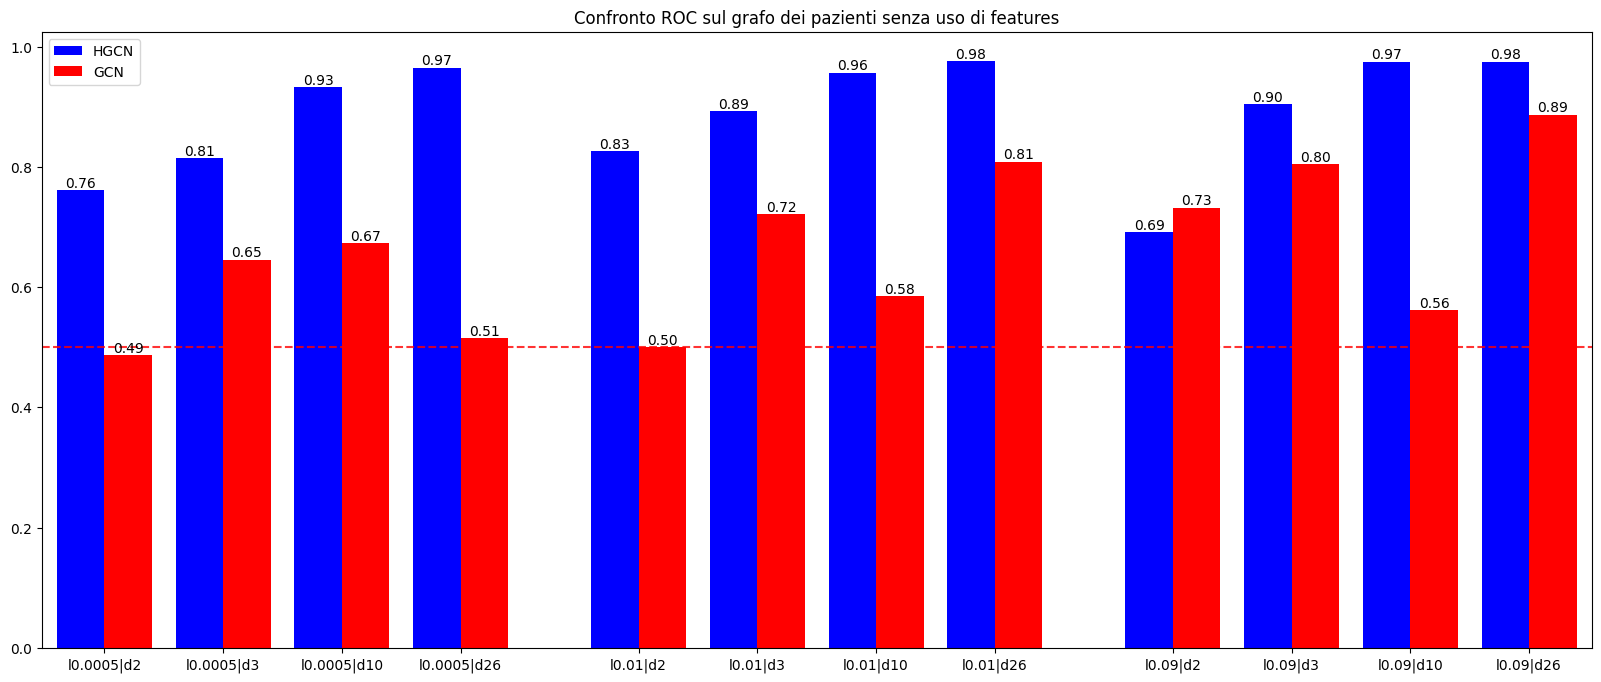

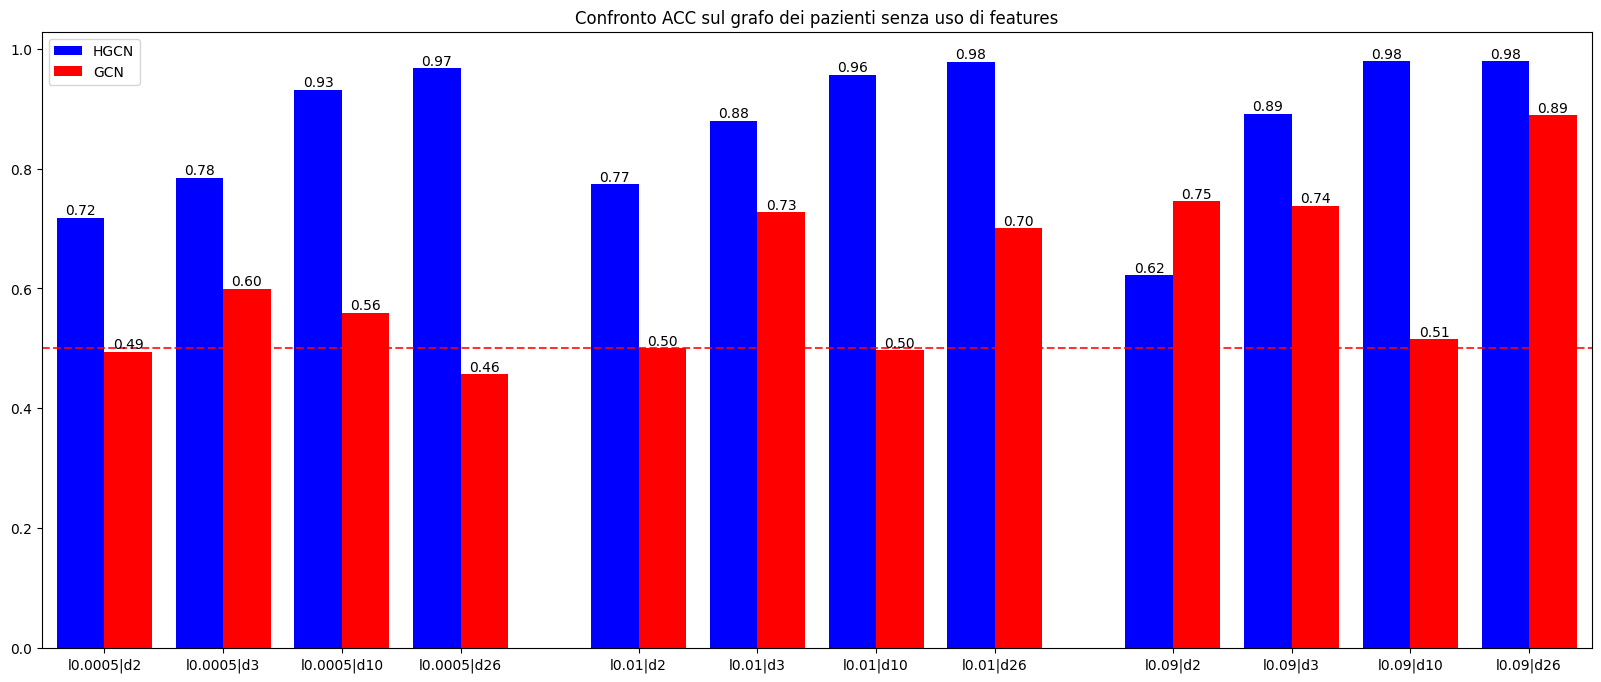

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(grid))
margin = 0.5
x = x + (x // 4) * margin
width = 0.4

plt.figure(figsize=(20, 8))
plt.axhline(0.5, color='red', linestyle='--', alpha=0.8)
plt.title("Confronto ROC sul grafo dei pazienti senza uso di features")

bars1 = plt.bar(x - width/2, all_test_roc, width, label='HGCN', color='blue')
bars2 = plt.bar(x + width/2, all_test_roc2, width, label='GCN', color='red')

plt.xticks(x, grid)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.margins(x=0.01)
plt.show()

plt.figure(figsize=(20, 8))
plt.axhline(0.5, color='red', linestyle='--', alpha=0.8)
plt.title("Confronto ACC sul grafo dei pazienti senza uso di features")

bars1 = plt.bar(x - width/2, all_test_ap, width, label='HGCN', color='blue')
bars2 = plt.bar(x + width/2, all_test_ap2, width, label='GCN', color='red')

plt.xticks(x, grid)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.margins(x=0.01)
plt.show()

In [5]:
z1 = []
z2 = []

for a, b in zip(all_test_ap, all_test_ap2):
    if a != 0:
        diff_percent = (b - a) / a * 100
        z1.append(diff_percent)
    else:
        print("Errore: divisione per zero")

for a, b in zip(all_test_roc, all_test_roc2):
    if a != 0:
        diff_percent = (b - a) / a * 100
        z2.append(diff_percent)
    else:
        print("Errore: divisione per zero")

print(f"La percentuale di guadagno di HGCN rispetto a GCN è:\n-Su ACC: {np.mean(z1):.2f}%\n-Su ROC: {np.mean(z2):.2f}%")
print(f"\nMaggior guadagno:\n-ACC: {grid[np.argmin(z1)]} ({np.min(z1):.2f})\n-ROC: {grid[np.argmin(z2)]} ({np.min(z2):.2f})")
print(f"\nMinor guadagno:\n-ACC: {grid[np.argmax(z1)]} ({np.max(z1):.2f})\n-ROC: {grid[np.argmax(z2)]} ({np.max(z2):.2f})")

La percentuale di guadagno di HGCN rispetto a GCN è:
-Su ACC: -27.56%
-Su ROC: -25.21%

Maggior guadagno:
-ACC: l0.0005|d26 (-52.80)
-ROC: l0.0005|d26 (-46.66)

Minor guadagno:
-ACC: l0.09|d2 (19.84)
-ROC: l0.09|d2 (5.99)


## Definisco funzione di peso per rendere esponenziale la crescita all'avvicinarsi a roc 0.98, per definire successivamente la funzione di efficienza

In [6]:
def weight(x):
    return np.exp(2.5*x)

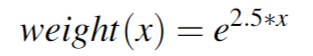

In [7]:
print(f"Tra 0.79 e 0.80:\t\t{weight(0.79):.3f} - {weight(0.8):.3f} ({(weight(0.8) - weight(0.79)):.3f})")
print(f"Tra 0.90 e 0.91:\t\t{weight(0.9):.3f} - {weight(0.91):.3f} ({(weight(0.91) - weight(0.9)):.3f})")

Tra 0.79 e 0.80:		7.207 - 7.389 (0.182)
Tra 0.90 e 0.91:		9.488 - 9.728 (0.240)


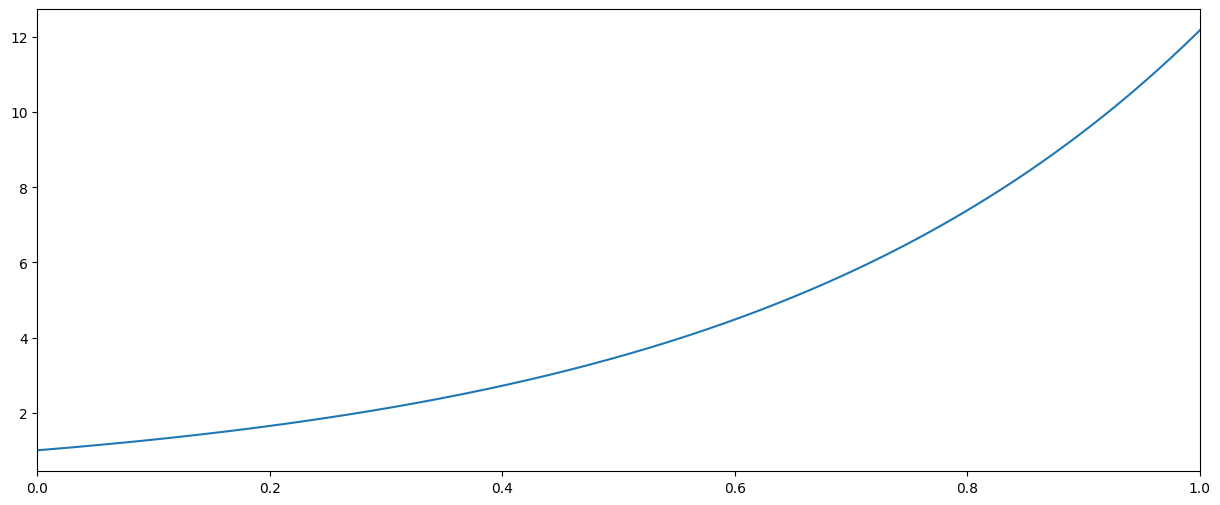

In [8]:
x = np.linspace(0, 1, 1000)
x2 = np.linspace(0, 1, 25)
plt.figure(figsize=(15, 6))
plt.plot(x, weight(x))
plt.xlim(0, 1)
plt.show()

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

root_dirs = [
    ("C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCNnoGF55", "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCNnoGF55"),
    ("C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCNnoGF57", "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCNnoGF57"),
    ("C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCNnoGF59", "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCNnoGF59")
]

rocHGCN, rocGCN = [], []
recallHGCN, recallGCN = [], []
precisionHGCN, precisionGCN = [], []
f1HGCN, f1GCN = [], []
AVGtimeHGCN, AVGtimeGCN = [], []
SUMtimeHGCN, SUMtimeGCN = [], []
TOT, TOT2 = [], []

for (p1, p2) in root_dirs:

    all_test_roc, all_test_ap, all_test_precision, all_test_recall, all_test_f1, tempi, total = carica_fileNew(p1, grid)
    all_test_roc2, all_test_ap2, all_test_precision2, all_test_recall2, all_test_f12, tempi2, total2 = carica_fileNew(p2, grid)
    
    TOT.append(total)
    TOT2.append(total2)
    
    t1 = [np.sum(x)*15 for x in tempi]
    t2 = [np.sum(x)*15 for x in tempi2]
    
    a1 = [np.mean(x) for x in tempi]
    a2 = [np.mean(x) for x in tempi2]
    
    SUMtimeHGCN.append(t1)
    SUMtimeGCN.append(t2)
    
    AVGtimeHGCN.append(a1)
    AVGtimeGCN.append(a2)
    
    rocHGCN.append(all_test_roc)
    rocGCN.append(all_test_roc2)
    recallHGCN.append(all_test_recall)
    recallGCN.append(all_test_recall2)
    precisionHGCN.append(all_test_precision)
    precisionGCN.append(all_test_precision2)
    f1HGCN.append(all_test_f1)
    f1GCN.append(all_test_f12)

effHGCN, effGCN = [], []
MeffHGCN, MeffGCN = [], []

for i in range(len(rocHGCN)):
    
    effHGCN.append((weight(np.array(rocHGCN[i]))/SUMtimeHGCN[i]))
    effGCN.append((weight(np.array(rocGCN[i]))/SUMtimeGCN[i]))

    MeffHGCN.append(np.array(rocHGCN[i])/AVGtimeHGCN[i])
    MeffGCN.append(np.array(rocGCN[i])/AVGtimeGCN[i])

## Confronto tra metriche

In [12]:
roc = [[np.mean(np.array(rocHGCN), axis=0)[i::4].mean() for i in range(4)], [np.mean(np.array(rocGCN), axis=0)[i::4].mean() for i in range(4)]]
f1 = [[np.mean(np.array(f1HGCN), axis=0)[i::4].mean() for i in range(4)], [np.mean(np.array(f1GCN), axis=0)[i::4].mean() for i in range(4)]]
recall = [[np.mean(np.array(recallHGCN), axis=0)[i::4].mean() for i in range(4)], [np.mean(np.array(recallGCN), axis=0)[i::4].mean() for i in range(4)]]
precision = [[np.mean(np.array(precisionHGCN), axis=0)[i::4].mean() for i in range(4)], [np.mean(np.array(precisionGCN), axis=0)[i::4].mean() for i in range(4)]]

rocd = [[np.std(np.array(rocHGCN), axis=0)[i::4].std() for i in range(4)], [np.std(np.array(rocGCN), axis=0)[i::4].std() for i in range(4)]]
f1d = [[np.std(np.array(f1HGCN), axis=0)[i::4].std() for i in range(4)], [np.std(np.array(f1GCN), axis=0)[i::4].std() for i in range(4)]]
recalld = [[np.std(np.array(recallHGCN), axis=0)[i::4].std() for i in range(4)], [np.std(np.array(recallGCN), axis=0)[i::4].std() for i in range(4)]]
precisiond = [[np.std(np.array(precisionHGCN), axis=0)[i::4].std() for i in range(4)], [np.std(np.array(precisionGCN), axis=0)[i::4].std() for i in range(4)]]


models = ["HGCN", "GCN"]
for m in range(len(models)):
    print(f"{models[m]}\t\t", end="")
    for i in ["dim 2", "dim 4", "dim 10", "dim 26"]:
        print(i, end="\t\t")

    print("\nROC-AUC", end="\t\t")
    for i in range(len(roc[m])):
        print(f"{roc[m][i]:.2f}", end="\t")
        print(f"{rocd[m][i]:.3f}", end="\t")

    print("\nPrecision", end="\t")
    for i in range(len(precision[m])):
        print(f"{precision[m][i]:.2f}", end="\t")
        print(f"{precisiond[m][i]:.3f}", end="\t")

    print("\nRecall", end="\t\t")
    for i in range(len(recall[m])):
        print(f"{recall[m][i]:.2f}", end="\t")
        print(f"{recalld[m][i]:.3f}", end="\t")

    print("\nF1-scor", end="\t\t")
    for i in range(len(f1[m])):
        print(f"{f1[m][i]:.2f}", end="\t")
        print(f"{f1d[m][i]:.3f}", end="\t")

    print("\n")

HGCN		dim 2		dim 4		dim 10		dim 26		
ROC-AUC		0.74	0.017	0.83	0.095	0.96	0.004	0.97	0.000	
Precision	0.66	0.009	0.76	0.044	0.91	0.013	0.94	0.002	
Recall		0.85	0.003	0.79	0.124	0.91	0.009	0.92	0.007	
F1-scor		0.74	0.014	0.77	0.099	0.91	0.004	0.93	0.004	

GCN		dim 2		dim 4		dim 10		dim 26		
ROC-AUC		0.55	0.017	0.74	0.015	0.67	0.024	0.73	0.027	
Precision	0.24	0.005	0.58	0.012	0.58	0.020	0.62	0.030	
Recall		0.42	0.005	0.91	0.038	0.90	0.014	0.94	0.003	
F1-scor		0.30	0.004	0.70	0.012	0.70	0.013	0.75	0.023	



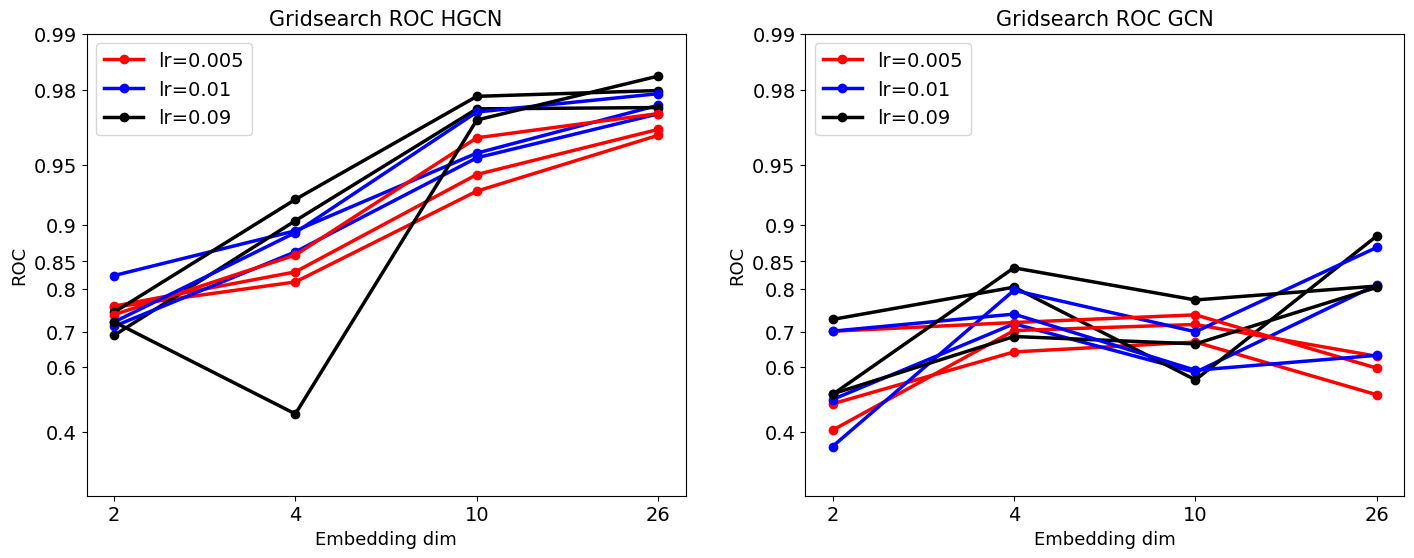

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from utilities import gridsearch

color = ["red", "blue", "black"]

dims = [2, 4, 10, 26]
lrs = [0.005, 0.01, 0.09]

gridsearch(color, dims, lrs, rocHGCN, rocGCN, "Gridsearch ROC", "ROC")

## Confronto diretto HGCN vs GCN

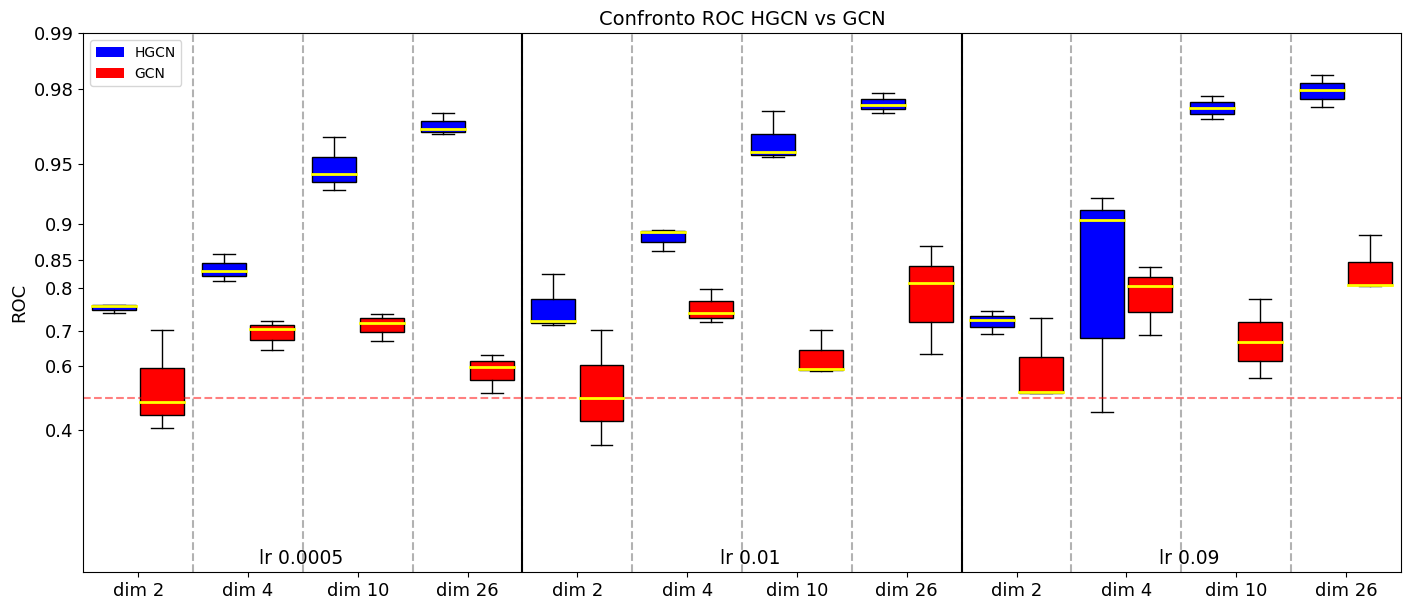

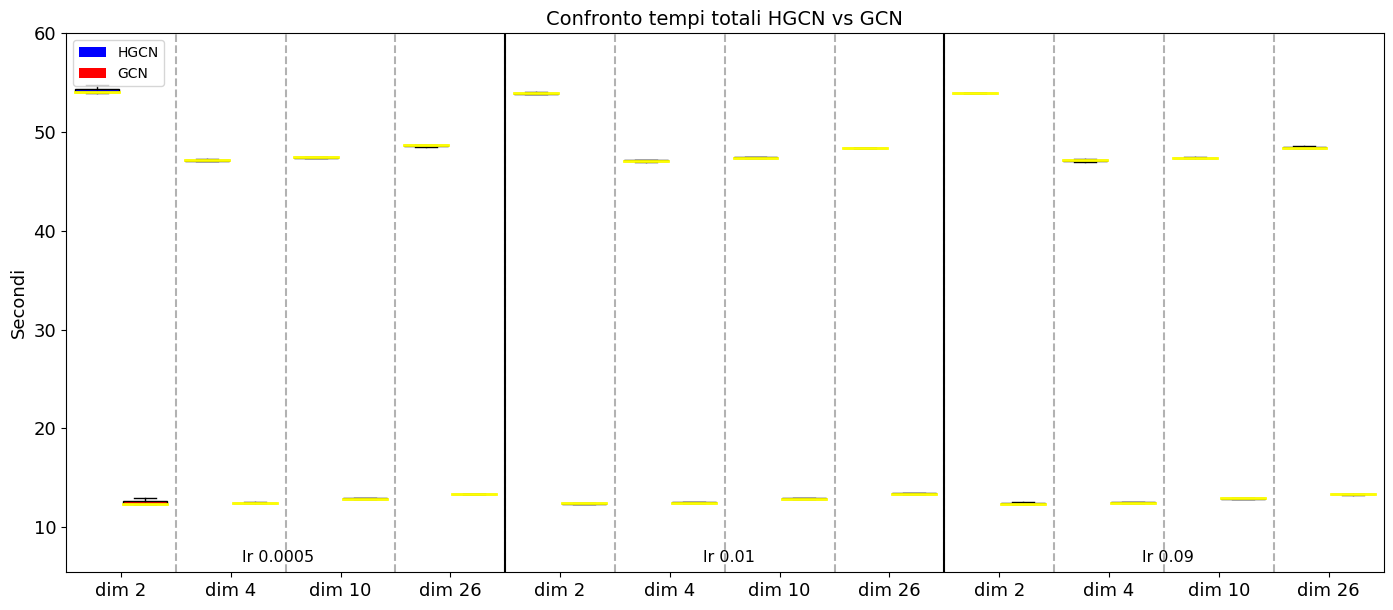

In [11]:
from utilities import boxes

boxes(grid, rocHGCN, rocGCN, "Confronto ROC HGCN vs GCN", "ROC")
boxes(grid, SUMtimeHGCN, SUMtimeGCN, "Confronto tempi totali HGCN vs GCN", "Secondi", True)

## Andamento ROC e tempo per combinazione di parametri e HGCN vs GCN

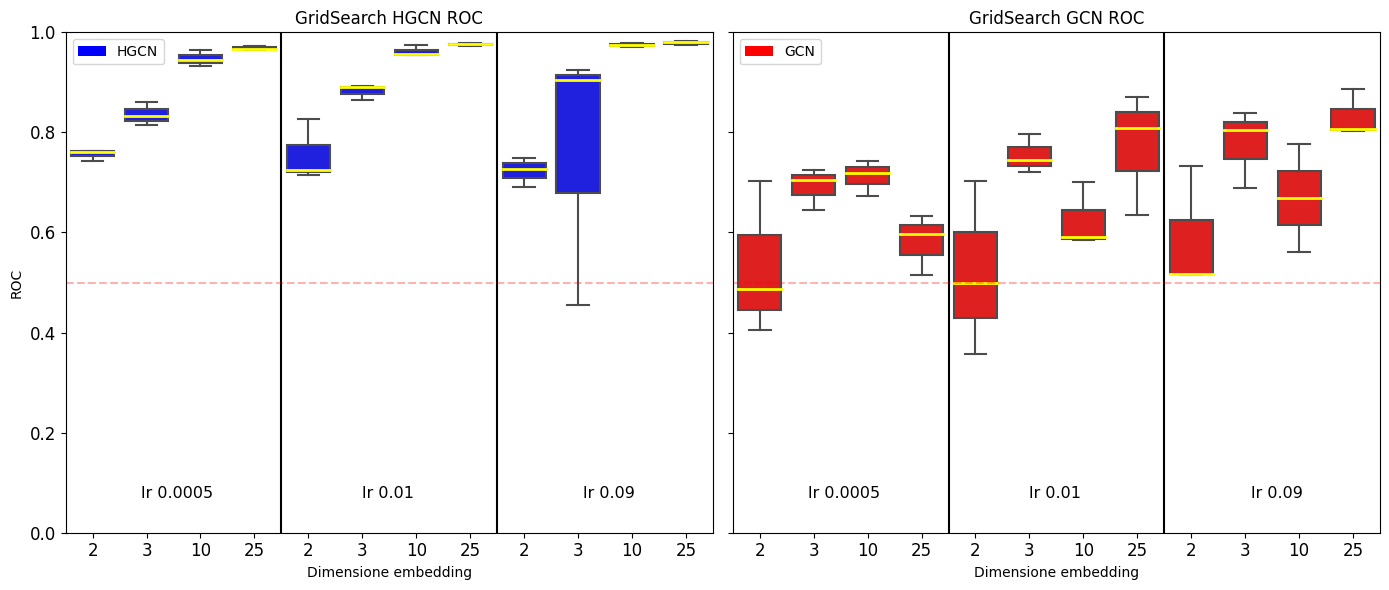

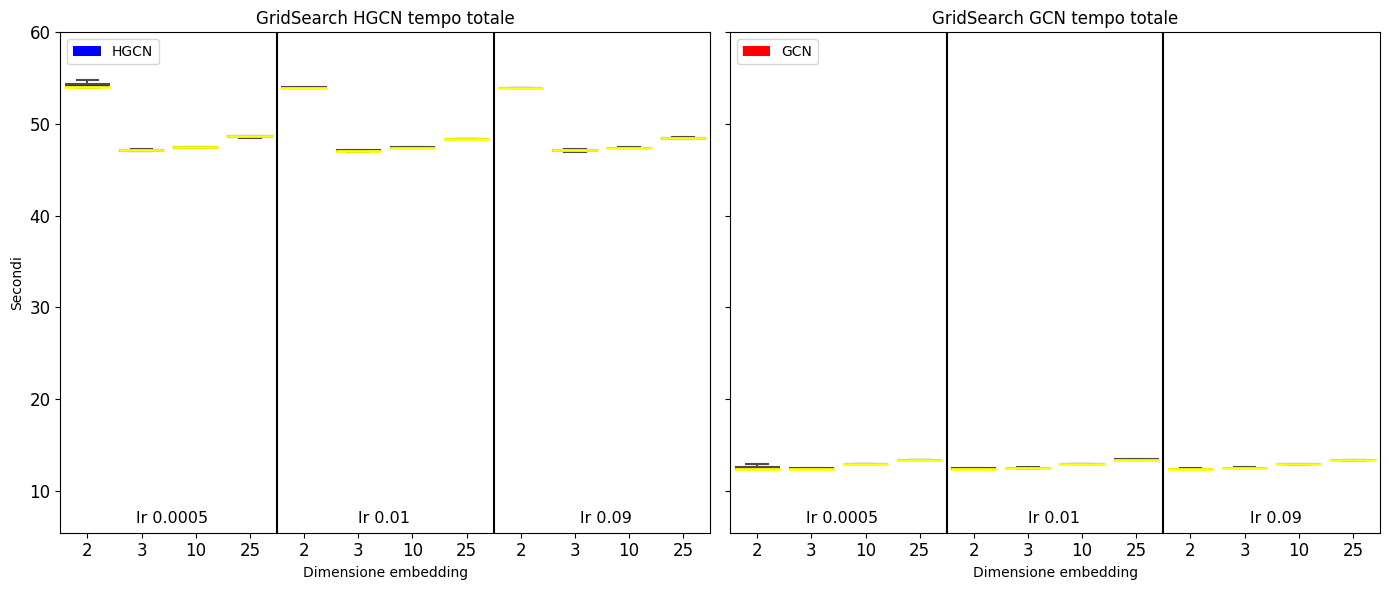

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from utilities import andamentoBOX

andamentoBOX(rocHGCN, rocGCN, "ROC", "ROC", True)
andamentoBOX(SUMtimeHGCN, SUMtimeGCN, "tempo totale", "Secondi", False, True)

## Analisi efficienza

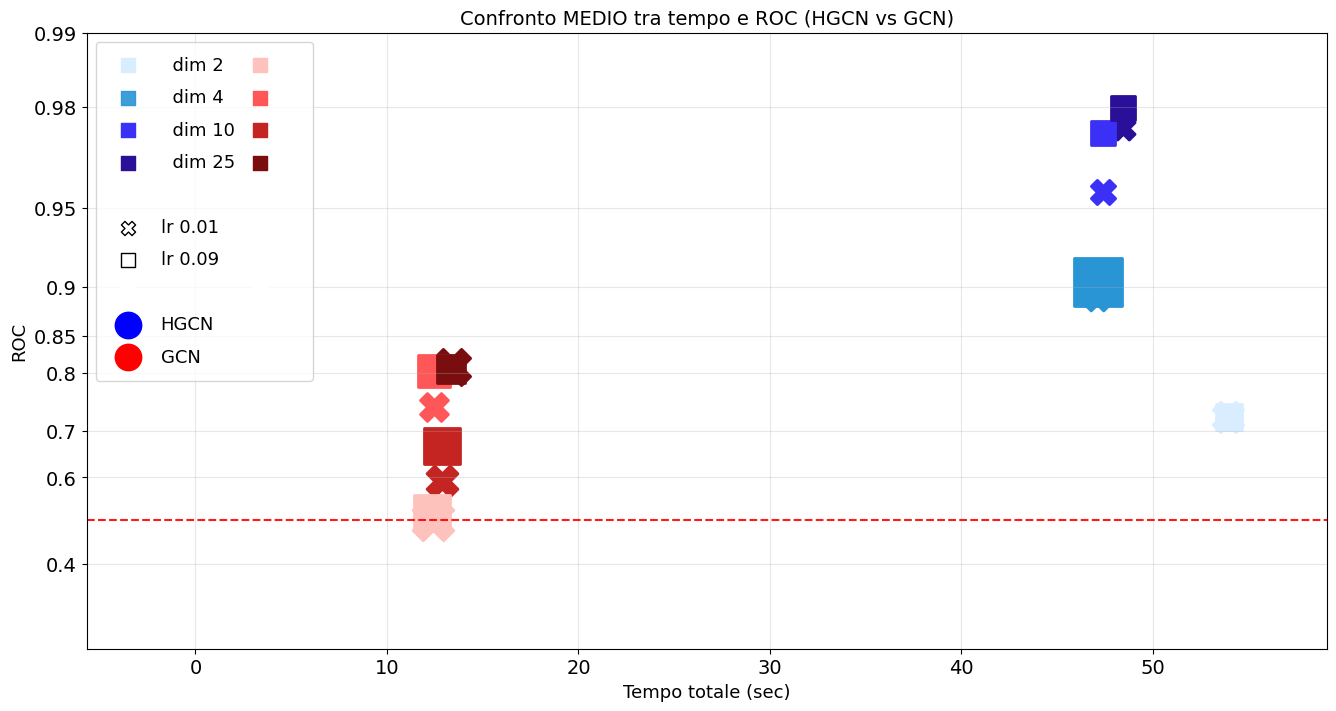

In [14]:
from utilities import scatterP

l = 0
TH, TG = [0]*3, [0]*3
DH, DG = [0]*3, [0]*3

for i in range(3):
    j = 4*l
    f = (4*l)+4

    TH[i] = SUMtimeHGCN[i][:j] + SUMtimeHGCN[i][f:]
    TG[i]  = SUMtimeGCN[i][:j] + SUMtimeGCN[i][f:]
    DH[i] = rocHGCN[i][:j] + rocHGCN[i][f:]
    DG[i] = rocGCN[i][:j] + rocGCN[i][f:]
scatterP(TH, TG, DH, DG, l, "Confronto MEDIO tra tempo e ROC (HGCN vs GCN)", "ROC")

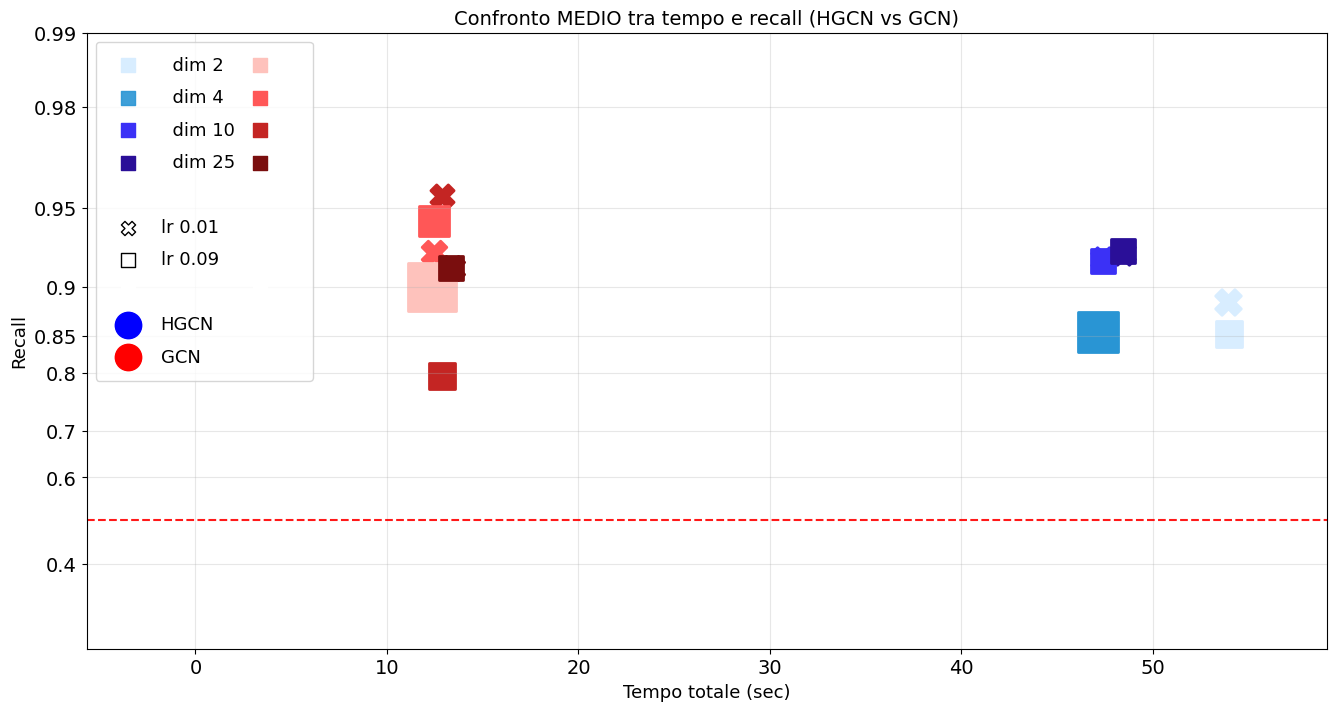

In [15]:
from utilities import scatterP

l = 0
TH, TG = [0]*3, [0]*3
DH, DG = [0]*3, [0]*3

for i in range(3):
    j = 4*l
    f = (4*l)+4

    TH[i] = SUMtimeHGCN[i][:j] + SUMtimeHGCN[i][f:]
    TG[i]  = SUMtimeGCN[i][:j] + SUMtimeGCN[i][f:]
    DH[i] = recallHGCN[i][:j] + recallHGCN[i][f:]
    DG[i] = recallGCN[i][:j] + recallGCN[i][f:]
scatterP(TH, TG, DH, DG, l, "Confronto MEDIO tra tempo e recall (HGCN vs GCN)", "Recall")

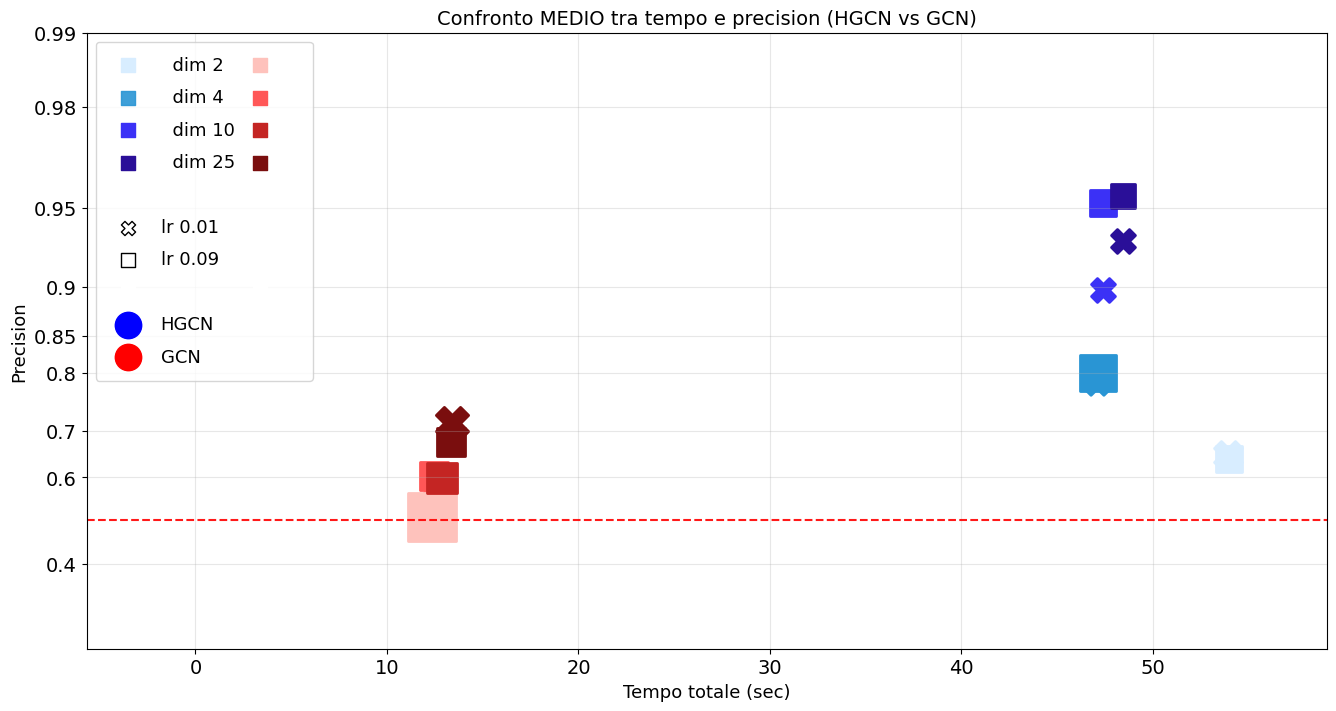

In [16]:
from utilities import scatterP

l = 0
TH, TG = [0]*3, [0]*3
DH, DG = [0]*3, [0]*3

for i in range(3):
    j = 4*l
    f = (4*l)+4

    TH[i] = SUMtimeHGCN[i][:j] + SUMtimeHGCN[i][f:]
    TG[i]  = SUMtimeGCN[i][:j] + SUMtimeGCN[i][f:]
    DH[i] = precisionHGCN[i][:j] + precisionHGCN[i][f:]
    DG[i] = precisionGCN[i][:j] + precisionGCN[i][f:]
scatterP(TH, TG, DH, DG, l, "Confronto MEDIO tra tempo e precision (HGCN vs GCN)", "Precision")

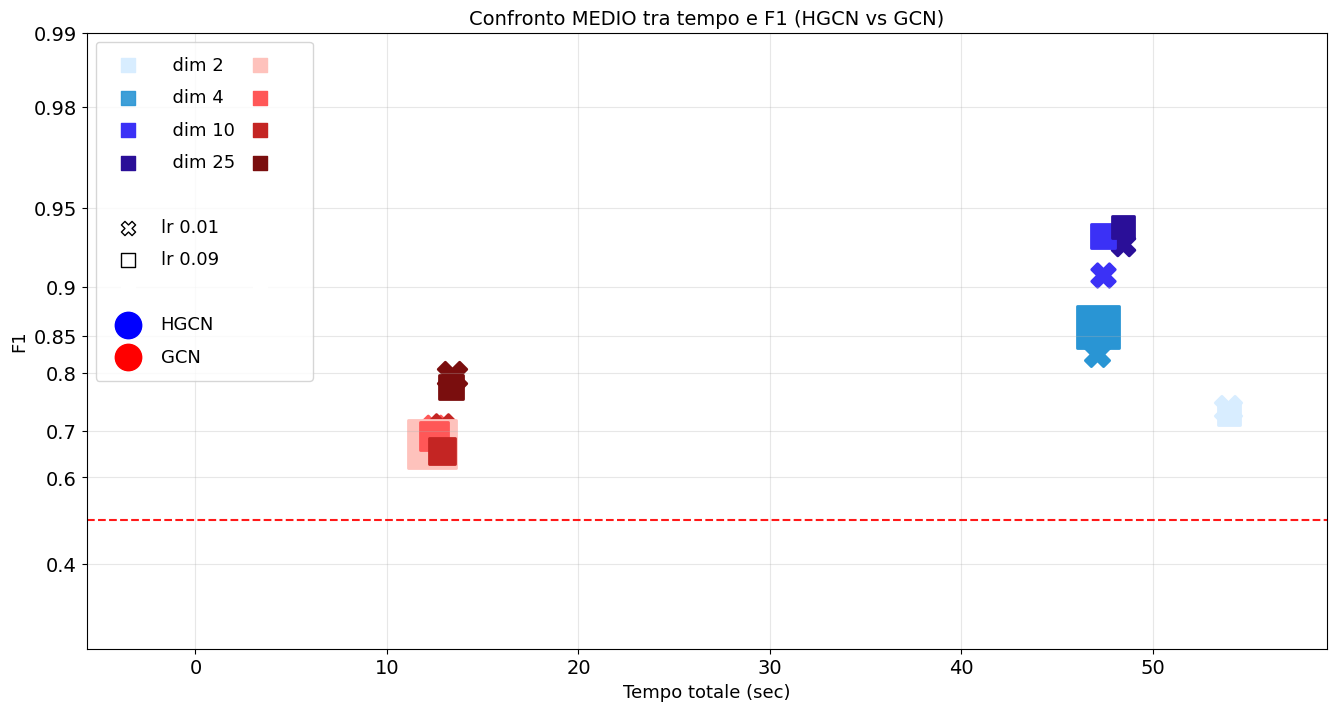

In [17]:
from utilities import scatterP

l = 0
TH, TG = [0]*3, [0]*3
DH, DG = [0]*3, [0]*3

for i in range(3):
    j = 4*l
    f = (4*l)+4

    TH[i] = SUMtimeHGCN[i][:j] + SUMtimeHGCN[i][f:]
    TG[i]  = SUMtimeGCN[i][:j] + SUMtimeGCN[i][f:]
    DH[i] = f1HGCN[i][:j] + f1HGCN[i][f:]
    DG[i] = f1GCN[i][:j] + f1GCN[i][f:]
scatterP(TH, TG, DH, DG, l, "Confronto MEDIO tra tempo e F1 (HGCN vs GCN)", "F1")